# **🚀 1. IMPORT THƯ VIỆN**

In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
np.set_printoptions(precision=4, suppress=True)
pd.options.display.max_columns = 50

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use(['seaborn-v0_8', 'seaborn-v0_8-whitegrid'])
%config InlineBackend.figure_format = 'retina'

from sklearn.tree import DecisionTreeClassifier, plot_tree

# **🧹 2. DATA CLEANING**

In [2]:
test = pd.read_csv('/kaggle/input/datasets/thvann81/dazone25/test.csv')
test

,user_id,merchant_id,label
0,52307,1393,0
1,182730,1890,0
2,92119,423,0
3,339138,4129,0
4,121953,2821,0
...,...,...,...
52690,1925,3266,0
52691,55363,4079,0
52692,68457,742,0
52693,15500,4589,0


In [3]:
test.info()
test.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52695 entries, 0 to 52694
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      52695 non-null  int64
 1   merchant_id  52695 non-null  int64
 2   label        52695 non-null  int64
dtypes: int64(3)
memory usage: 1.2 MB


user_id        0
merchant_id    0
label          0
dtype: int64

In [4]:
train = pd.read_csv('/kaggle/input/datasets/thvann81/dazone25/train.csv')
train

,user_id,merchant_id,label
0,393595.0,794.0,0.0
1,287580.0,2447.0,0.0
2,203618.0,598.0,0.0
3,143560.0,2030.0,0.0
4,324173.0,1875.0,0.0
...,...,...,...
233777,NaN,NaN,1.0
233778,NaN,2036.0,1.0
233779,174089.0,1760.0,-1.0
233780,NaN,NaN,1.0


In [25]:
# English Comment: Remove invalid labels (-1.0) from the Train set to ensure a clean binary classification task.
train = train[train['label'] != -1]

# Kiểm tra lại để chắc chắn
print("Các nhãn còn lại trong bảng Train:", train['label'].unique())

Các nhãn còn lại trong bảng Train: [0. 1.]


In [5]:
train.info()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233782 entries, 0 to 233781
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   user_id      228192 non-null  float64
 1   merchant_id  228284 non-null  float64
 2   label        233782 non-null  float64
dtypes: float64(3)
memory usage: 5.4 MB


user_id        5590
merchant_id    5498
label             0
dtype: int64

In [6]:
user_info =pd.read_csv('/kaggle/input/datasets/thvann81/dazone25/user_info.csv')
user_info

,user_id,age,sex,phone,job,carrier,marital_status
0,376517,44.0,gentle,******6654,Thực tập sinh giáo dục,other,Married
1,234512,39.0,lady,NaN,NaN,vietnamobile,Married
2,344532,39.0,she,******6296,DevOps Engineer,other,cưới
3,186135,37.0,she,******1502,Thực tập sinh giáo dục,vietnamobile,cưới
4,30230,38.0,female,******4966,DevOps Engineer,viettel,Married
...,...,...,...,...,...,...,...
424165,395814,26.0,gеntle,******8563,Kiến trúc sư phần mềm,vinaphone,Married
424166,245950,NaN,male,*****3449,Tư vấn khách hàng,other,Divorced
424167,208016,NaN,unknown,******7187,Trưởng phòng kinh doanh,viettel,Married
424168,272535,45.0,M,*******0404,Dược sĩ,vinaphone,cưới


In [7]:
user_info['sex'].value_counts()

sex
F          47868
lady       47144
girl       47006
she        47004
woman      46806
female     46044
M          20297
boy        20210
men        20081
male       20037
he         19890
gentle     19844
unknown     5532
other       5514
femаle       498
gіrl         487
womаn        487
shе          477
fеmale       461
lаdy         450
femalе       448
wοman        444
hе           203
mеn          201
gеntle       196
gentlе       183
mаle         181
bοy          178
malе         167
othеr         65
սnknown       62
οther         61
unknοwn       57
nսll          53
femаlе         4
fеmаle         4
fеmalе         3
wοmаn          3
mаlе           1
gеntlе         1
Name: count, dtype: int64

In [8]:
# English Comment: Clean and standardize gender labels. 
# Step 1: Strip whitespace to handle cases like ' female ' vs 'female'
user_info['sex'] = user_info['sex'].astype(str).str.strip().str.lower()

# Step 2: Define mapping for all variations found in value_counts()
gender_map = {
    'f': 'Female', 'female': 'Female', 'woman': 'Female', 'girl': 'Female', 'she': 'Female', 'lady': 'Female',
    'm': 'Male', 'male': 'Male', 'man': 'Male', 'boy': 'Male', 'he': 'Male', 'gentle': 'Male',
    'unknown': 'Unknown', 'other': 'Unknown', 'null': 'Unknown', 'nan': 'Unknown'
}

# Apply mapping. Any value not in the map becomes 'Unknown'
user_info['sex'] = user_info['sex'].map(gender_map).fillna('Unknown')

# Verify the result
print(user_info['sex'].value_counts())

sex
Female     281872
Male       100278
Unknown     42020
Name: count, dtype: int64


Cột giới tính **(sex)** ban đầu chứa hàng chục nhãn khác nhau cho cùng một giá trị (ví dụ: F, lady, girl, she đều chỉ giới tính Nữ) và bị lỗi khoảng trắng.

**Giải pháp xử lý:** Tôi đã thực hiện chuẩn hóa dữ liệu bằng cách chuyển về chữ thường, xóa khoảng trắng thừa và sử dụng kỹ thuật Mapping để quy gom toàn bộ về 3 nhóm chính: **Male, Female, và Unknown**. 

Việc chuẩn hóa này là bắt buộc để mô hình dự đoán có thể hiểu đúng đặc điểm nhân khẩu học của khách hàng. Đồng thời, biểu đồ sau chuẩn hóa sẽ cung cấp một cái nhìn chính xác về tỷ lệ khách hàng, giúp doanh nghiệp (Viettel) đưa ra các chiến dịch tiếp thị cá nhân hóa hiệu quả hơn.

In [9]:
user_info.info()
user_info.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         424170 non-null  int64  
 1   age             328803 non-null  float64
 2   sex             424170 non-null  object 
 3   phone           402962 non-null  object 
 4   job             402962 non-null  object 
 5   carrier         402962 non-null  object 
 6   marital_status  423813 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 22.7+ MB


,user_id,age
count,424170.000000,328803.000000
mean,212085.500000,32.064674
std,122447.476178,32.842554
min,1.000000,-1.000000
25%,106043.250000,26.000000
50%,212085.500000,29.000000
75%,318127.750000,35.000000
max,424170.000000,999.000000


In [10]:
user_info.isnull().sum()

user_id               0
age               95367
sex                   0
phone             21208
job               21208
carrier           21208
marital_status      357
dtype: int64

In [11]:
user_log = pd.read_csv('/kaggle/input/datasets/thvann81/dazone25/user_log.csv')
user_log.info()
user_log

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54925330 entries, 0 to 54925329
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_id      int64  
 1   item_id      int64  
 2   cat_id       int64  
 3   brand_id     float64
 4   merchant_id  int64  
 5   action       object 
 6   datetime     object 
dtypes: float64(1), int64(4), object(2)
memory usage: 2.9+ GB


,user_id,item_id,cat_id,brand_id,merchant_id,action,datetime
0,328862,323294,833,2661.0,2882,click,2024-08-29
1,328862,844400,1271,2661.0,2882,click,2024-08-29
2,328862,575153,1271,2661.0,2882,click,2024-08-29
3,328862,996875,1271,2661.0,2882,click,2024-08-29
4,328862,1086186,1271,1049.0,1253,click,2024-08-29
...,...,...,...,...,...,...,...
54925325,208016,107662,898,7995.0,1346,click,2024-11-10
54925326,208016,1058313,898,7995.0,1346,click,2024-11-10
54925327,208016,449814,898,7995.0,983,click,2024-11-10
54925328,208016,634856,898,7995.0,1346,click,2024-11-10


In [12]:
user_log.isnull().sum()

user_id            0
item_id            0
cat_id             0
brand_id       91015
merchant_id        0
action             0
datetime           0
dtype: int64

In [36]:
# 1. Thống kê Missing Values
print("Tỉ lệ missing value (%) mỗi cột:")
print(user_log.isnull().sum() / len(user_log) * 100)

Tỉ lệ missing value (%) mỗi cột:
user_id        0.000000
item_id        0.000000
cat_id         0.000000
brand_id       0.212276
merchant_id    0.000000
action         0.000000
datetime       0.000000
date           0.000000
dtype: float64


In [13]:
# 1. Xử lý bảng train (Xóa các dòng thiếu ID quan trọng)
train = train.dropna(subset=['user_id', 'merchant_id'])

# 2. Xử lý Outliers cho Age trong user_info trước khi điền khuyết
import numpy as np
# Giả định tuổi hợp lý từ 1 đến 100
user_info.loc[(user_info['age'] <= 0) | (user_info['age'] > 100), 'age'] = np.nan

# 3. Điền khuyết cho Age bằng Median (lúc này median đã chuẩn hơn)
user_info['age'] = user_info['age'].fillna(user_info['age'].median())

# 4. Điền khuyết cho các cột phân loại
cat_cols = ['sex', 'phone', 'job', 'carrier', 'marital_status']
for col in cat_cols:
    user_info[col] = user_info[col].fillna("Unknown")

# 5. Kiểm tra lại
print("Missing values in train:\n", train.isnull().sum())
print("\nMissing values in user_info:\n", user_info.isnull().sum())
print("\nAge stats:\n", user_info['age'].describe())

Missing values in train:
 user_id        0
merchant_id    0
label          0
dtype: int64

Missing values in user_info:
 user_id           0
age               0
sex               0
phone             0
job               0
carrier           0
marital_status    0
dtype: int64

Age stats:
 count    424170.000000
mean         30.521878
std           7.135222
min          10.000000
25%          27.000000
50%          29.000000
75%          33.000000
max          77.000000
Name: age, dtype: float64


In [32]:
# Drop duplicates
print(f"Before dropping duplicates: {len(user_log)} rows")
user_info = user_info.drop_duplicates()

user_log = user_log.drop_duplicates()
print(f"After dropping duplicates: {len(user_log)} rows")

Before dropping duplicates: 41175132 rows
After dropping duplicates: 41175132 rows


**1. Đánh giá tính đầy đủ và chất lượng dữ liệu (Data Integrity)**
* **Bảng test:** Dữ liệu hoàn toàn sạch sẽ, không có giá trị khuyết thiếu (0 missing values), đảm bảo tính sẵn sàng cho việc đánh giá mô hình.
* **Bảng train:** Phát hiện sự thiếu hụt nghiêm trọng tại các cột định danh quan trọng như **user_id** (**5,590** dòng) và **merchant_id** (**5,498 dòng**). --> Việc thiếu ID người dùng và cửa hàng khiến các bản ghi này không có giá trị cho việc huấn luyện mô hình dự đoán hành vi quay lại mua hàng. Do đó, giải pháp tối ưu là loại bỏ các dòng này để đảm bảo độ chính xác cho mô hình (Data Cleaning).
* **Bảng user_log:** Cột **brand_id** thiếu đến **87,405** giá trị. --> Đây là hiện tượng phổ biến trong TMĐT khi nhiều sản phẩm không thuộc thương hiệu lớn hoặc hệ thống ghi nhận chưa kịp thời.

**2. Giá trị ngoại lai (Outliers)**
Dựa trên kết quả từ bảng user_info.describe():
* **Bất thường về Tuổi (Age):** Giá trị nhỏ nhất **(Min)** là **-1.0** và lớn nhất **(Max)** là **999.0**.
--> Đây là các điểm ngoại lai (outliers) phi thực tế. Tuổi âm có thể là mã hóa cho việc người dùng không cung cấp thông tin, trong khi tuổi 999 là lỗi nhập liệu hoặc giá trị mặc định của hệ thống cũ.
Chúng tôi Sử dụng giá trị trung vị (median = 29.0) là hợp lý vì độ lệch chuẩn của tuổi khá cao (std = 32.8), giúp ổn định lại phân phối dữ liệu mà không làm mất đi các thuộc tính quan trọng khác như **job** hay **carrier**.
* **Phân bổ Giới tính và Nghề nghiệp:** Việc thiếu hụt dữ liệu ở các cột **sex, phone, job, carrier** (từ **5,518** đến **21,208 dòng**) cho thấy một bộ phận người dùng ưu tiên tính bảo mật hoặc sàn chưa thu thập đầy đủ thông tin.

* Chúng tôi loại bỏ label -1.0 và xử lý tuổi 999 vì đây là các giá trị nhiễu không phản ánh đúng chân dung khách hàng thực tế

# **🔍 3. EDA**

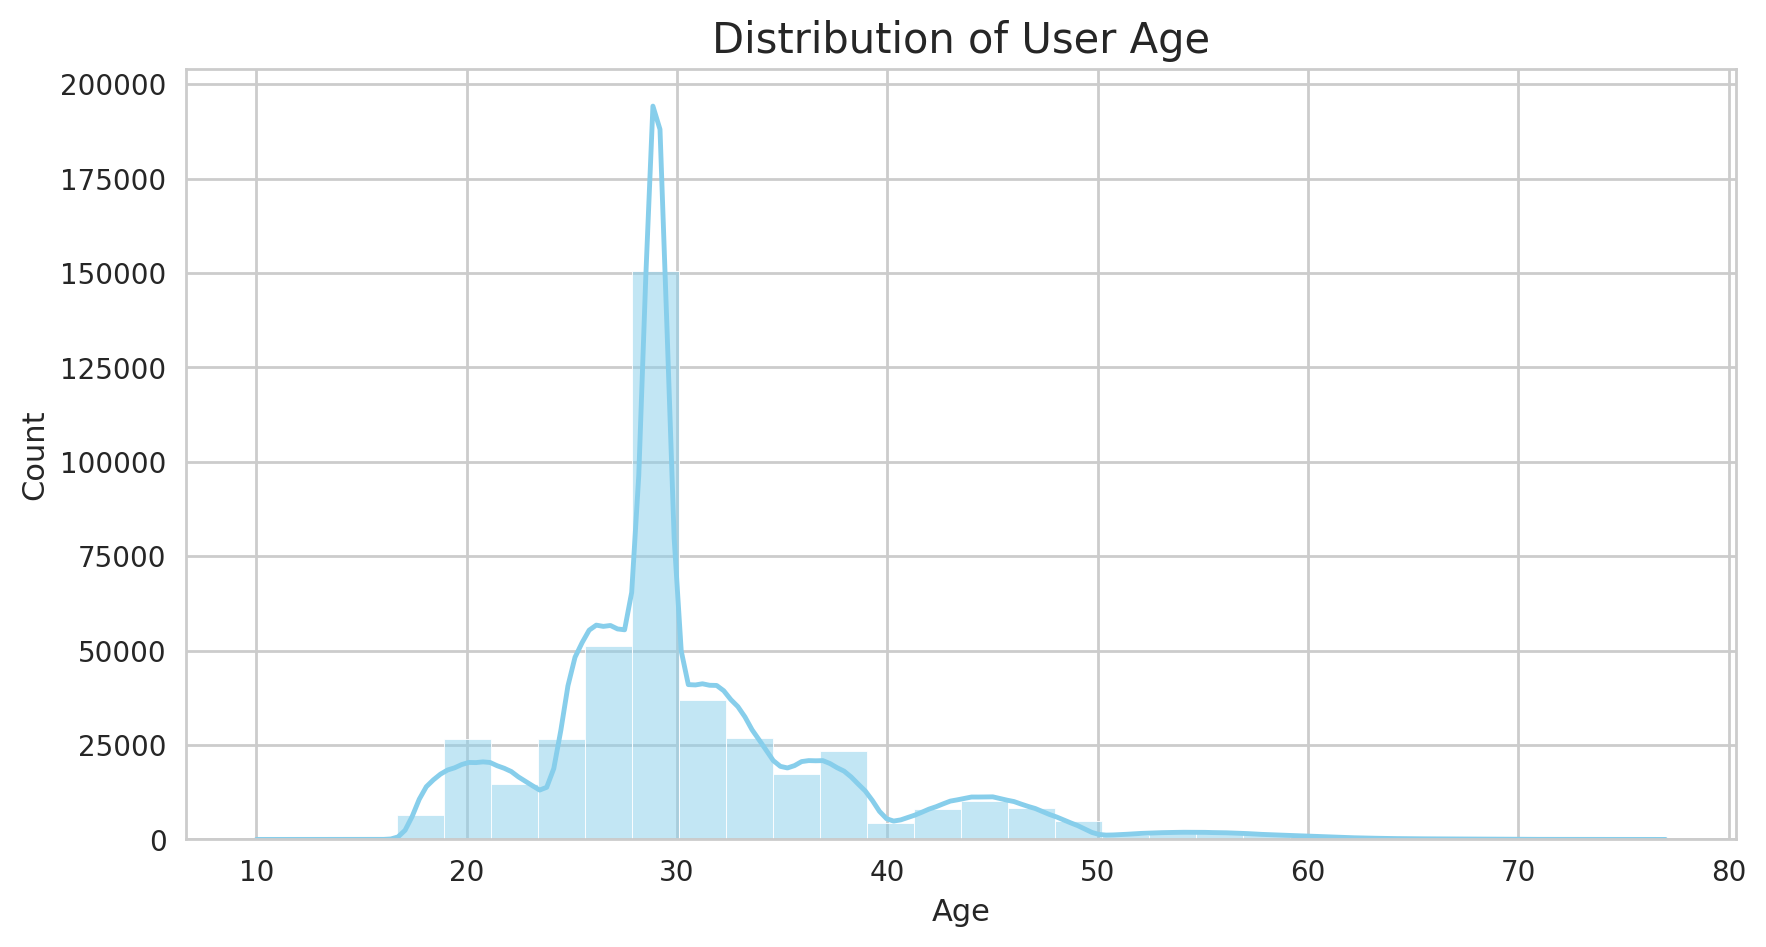

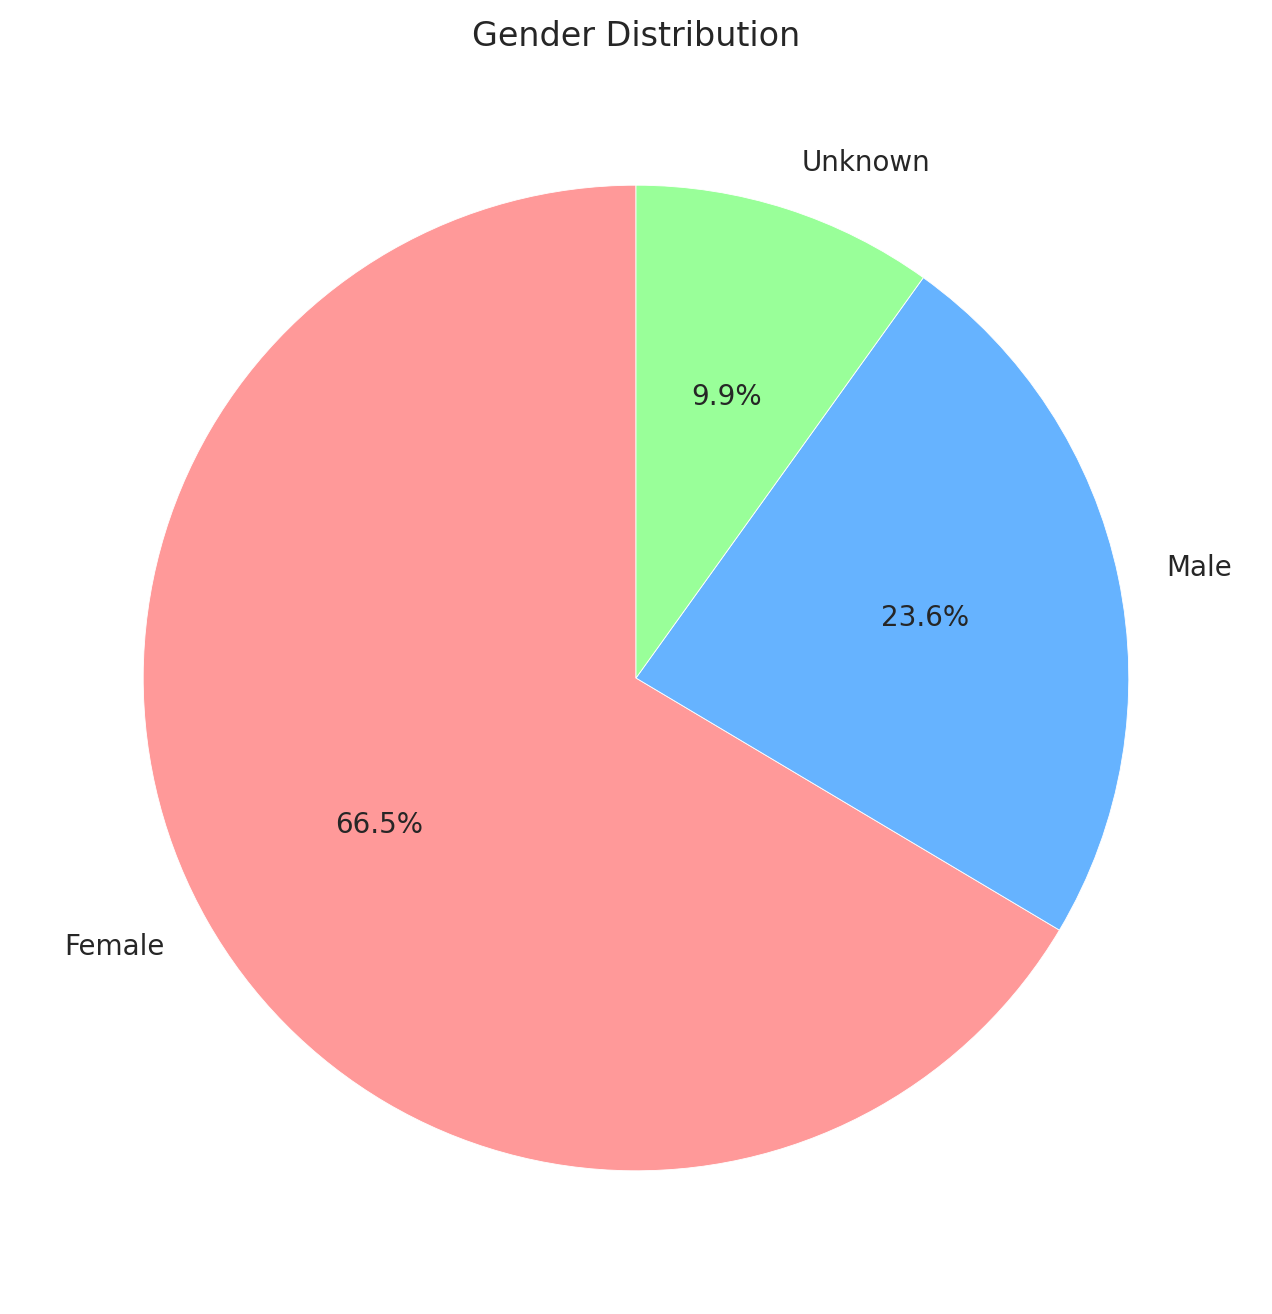

In [15]:
#1. Phân tích Nhân khẩu học (User Info EDA)

# Thiết lập style cho biểu đồ
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1.1 Phân bổ độ tuổi (Sau khi đã clean outliers)
plt.figure(figsize=(10, 5))
sns.histplot(user_info['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of User Age', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 1.2 Tỷ lệ giới tính (Gender Distribution)
plt.figure(figsize=(8, 8))
user_info['sex'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

**Phân tích Đặc điểm Nhân khẩu học (User Demographics Analysis)**

**1. Phân bổ Giới tính (Gender Distribution)**
* Sau khi chuẩn hóa các nhãn dữ liệu nhiễu, biểu đồ cho thấy khách hàng **Nữ (Female)** chiếm tỷ trọng áp đảo với **66.5%**, **gấp gần 3 lần** so với khách hàng **Nam (Male - 23.6%)**. Nhóm không xác định **(Unknown)** chỉ còn chiếm **9.9%.**

* **Insight kinh doanh:** Sàn Thương mại điện tử này đang có sức hút cực lớn đối với phái đẹp.

* **Hành động đề xuất:** Các chương trình khuyến mãi (như Sale ngày đôi) nên tập trung vào các ngành hàng thế mạnh của nữ giới như Mỹ phẩm, Thời trang, Chăm sóc sức khỏe gia đình để tối ưu hóa tỷ lệ chuyển đổi.

**2. Phân bổ Độ tuổi (Distribution of User Age)**
* Biểu đồ phân phối cho thấy một đỉnh nhọn **cực đại** ở **độ tuổi 29** (đây có thể là kết quả của việc điền giá trị Trung vị - Median cho các dữ liệu trống/ngoại lai trước đó). Đa số người dùng tập trung mạnh trong khoảng **20 - 40 tuổi**.

* **Insight kinh doanh:** Đối tượng khách hàng mục tiêu là **nhóm Millennials và Gen Z**. Đây là nhóm khách hàng trẻ, năng động, am hiểu công nghệ và có thói quen mua sắm online thường xuyên.

* **Phát hiện về "Deal Hunters":** Nhóm tuổi từ 20-30 thường là những người nhạy bén về giá nhất. Doanh nghiệp cần lưu ý nhóm này vì họ có khả năng cao thuộc nhóm "Deal Hunters" - chỉ xuất hiện khi có mã giảm giá lớn.

**3. Kết nối bài toán Doanh nghiệp (Viettel - DAZONE 2025)**
* Việc thấu hiểu chân dung khách hàng (Nữ giới, độ tuổi 20-40) là cơ sở để trả lời câu hỏi: "Khách hàng nào có tiềm năng trở thành khách hàng trung thành?".

* Bằng việc xác định rõ đối tượng mục tiêu, chúng ta có thể xây dựng các tính năng (Feature Engineering) chính xác hơn, ví dụ như tính toán tần suất mua sắm của nhóm nữ giới trẻ tuổi để dự đoán xác suất quay lại trong vòng 6 tháng tới.

In [17]:
# Convert datetime to proper format and extract date for trend analysis
user_log['datetime'] = pd.to_datetime(user_log['datetime'])
user_log['date'] = user_log['datetime'].dt.date

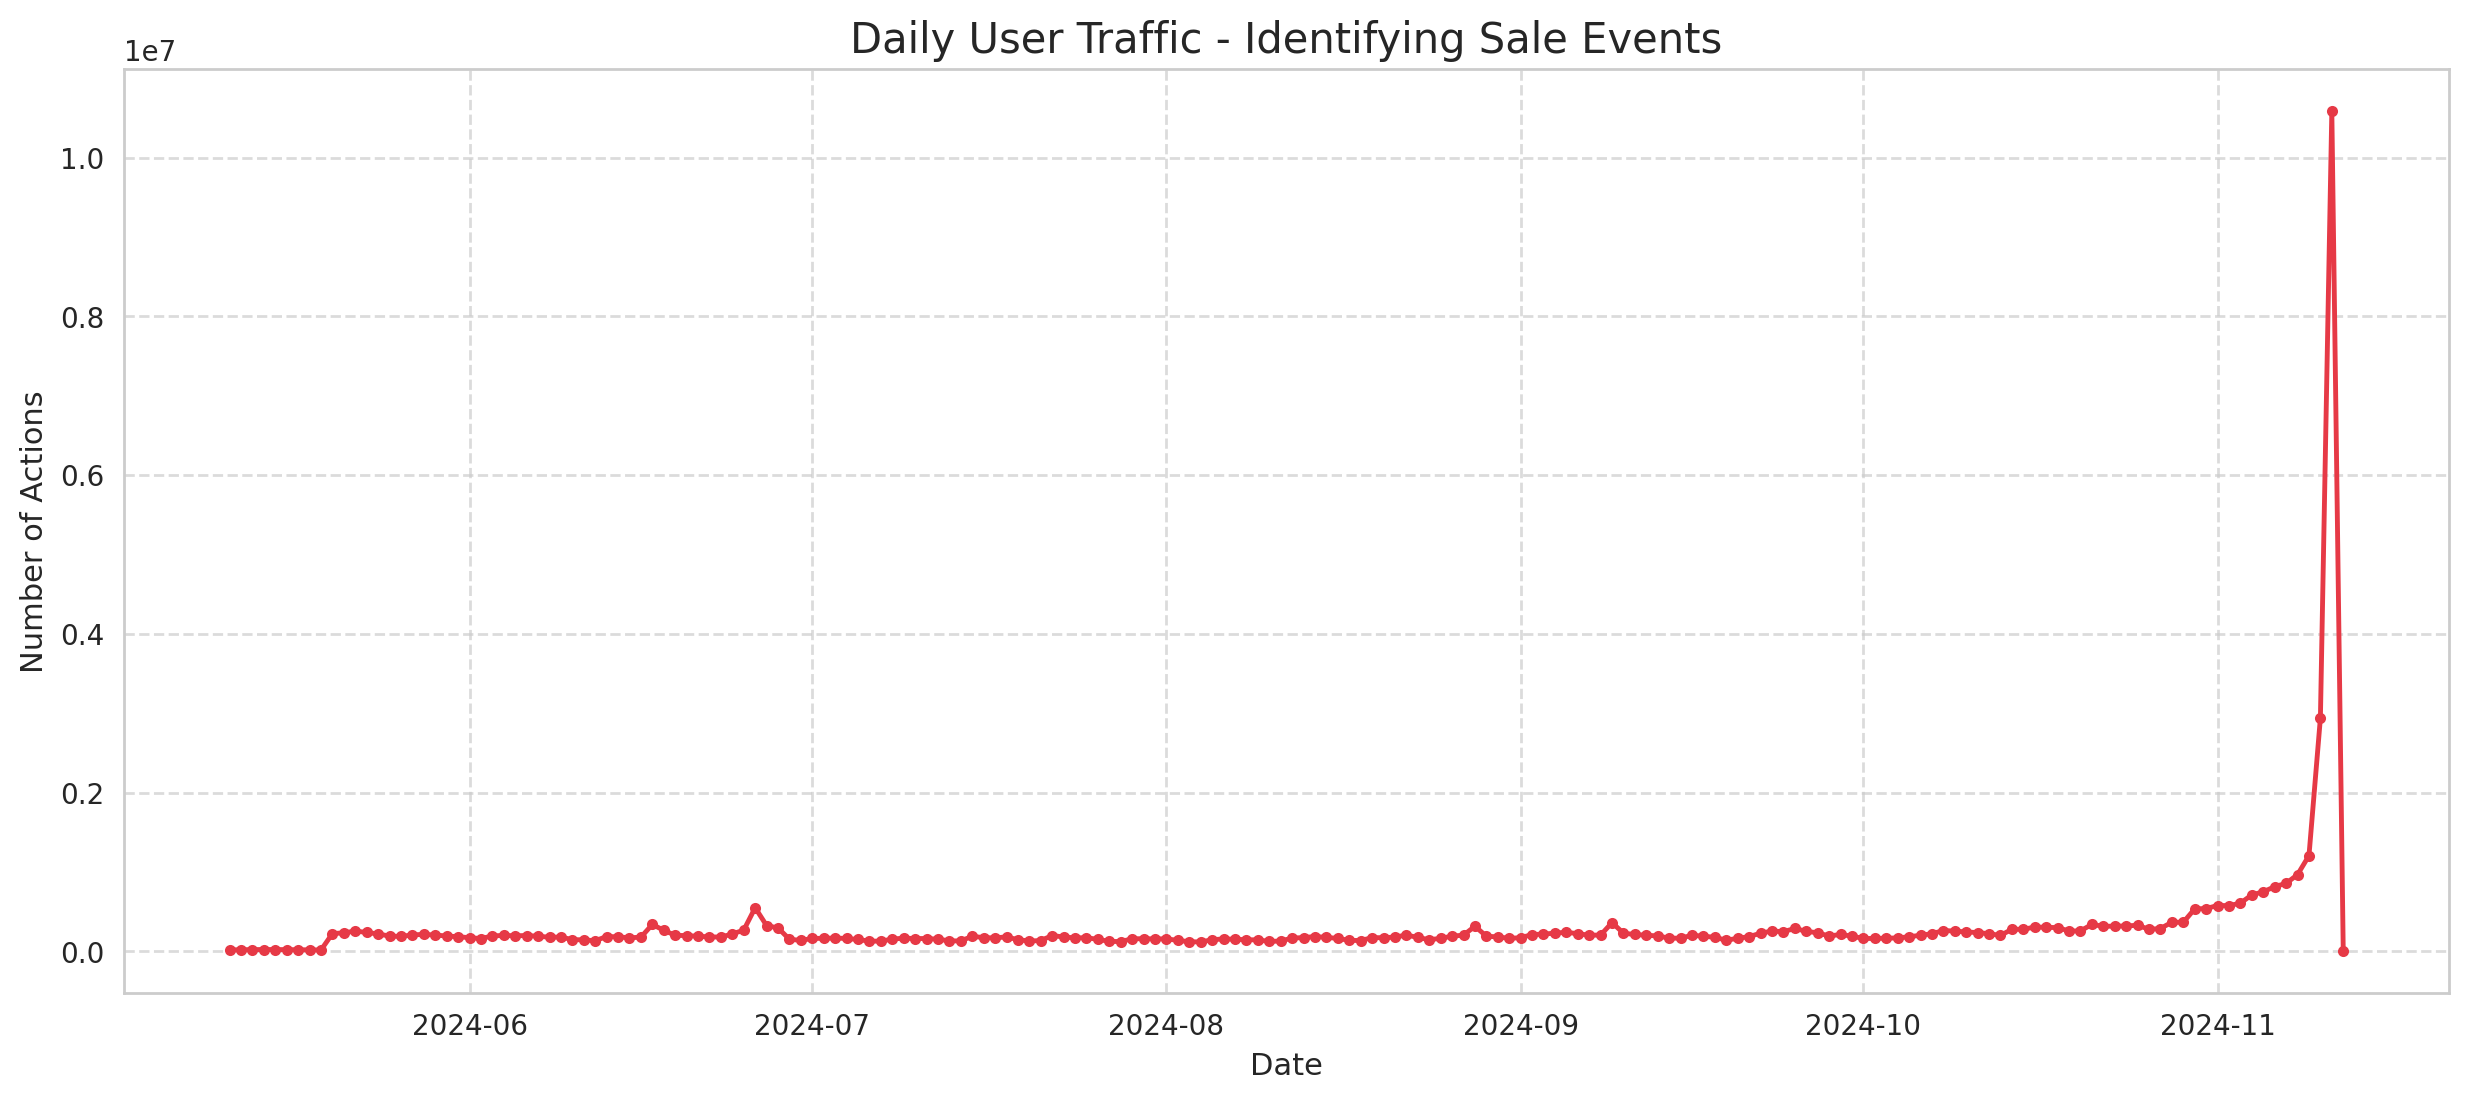

In [18]:
# Count actions per day
daily_traffic = user_log.groupby('date').size()

plt.figure(figsize=(15, 6))
daily_traffic.plot(kind='line', color='#e63946', marker='o', markersize=4)
plt.title('Daily User Traffic - Identifying Sale Events', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Number of Actions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

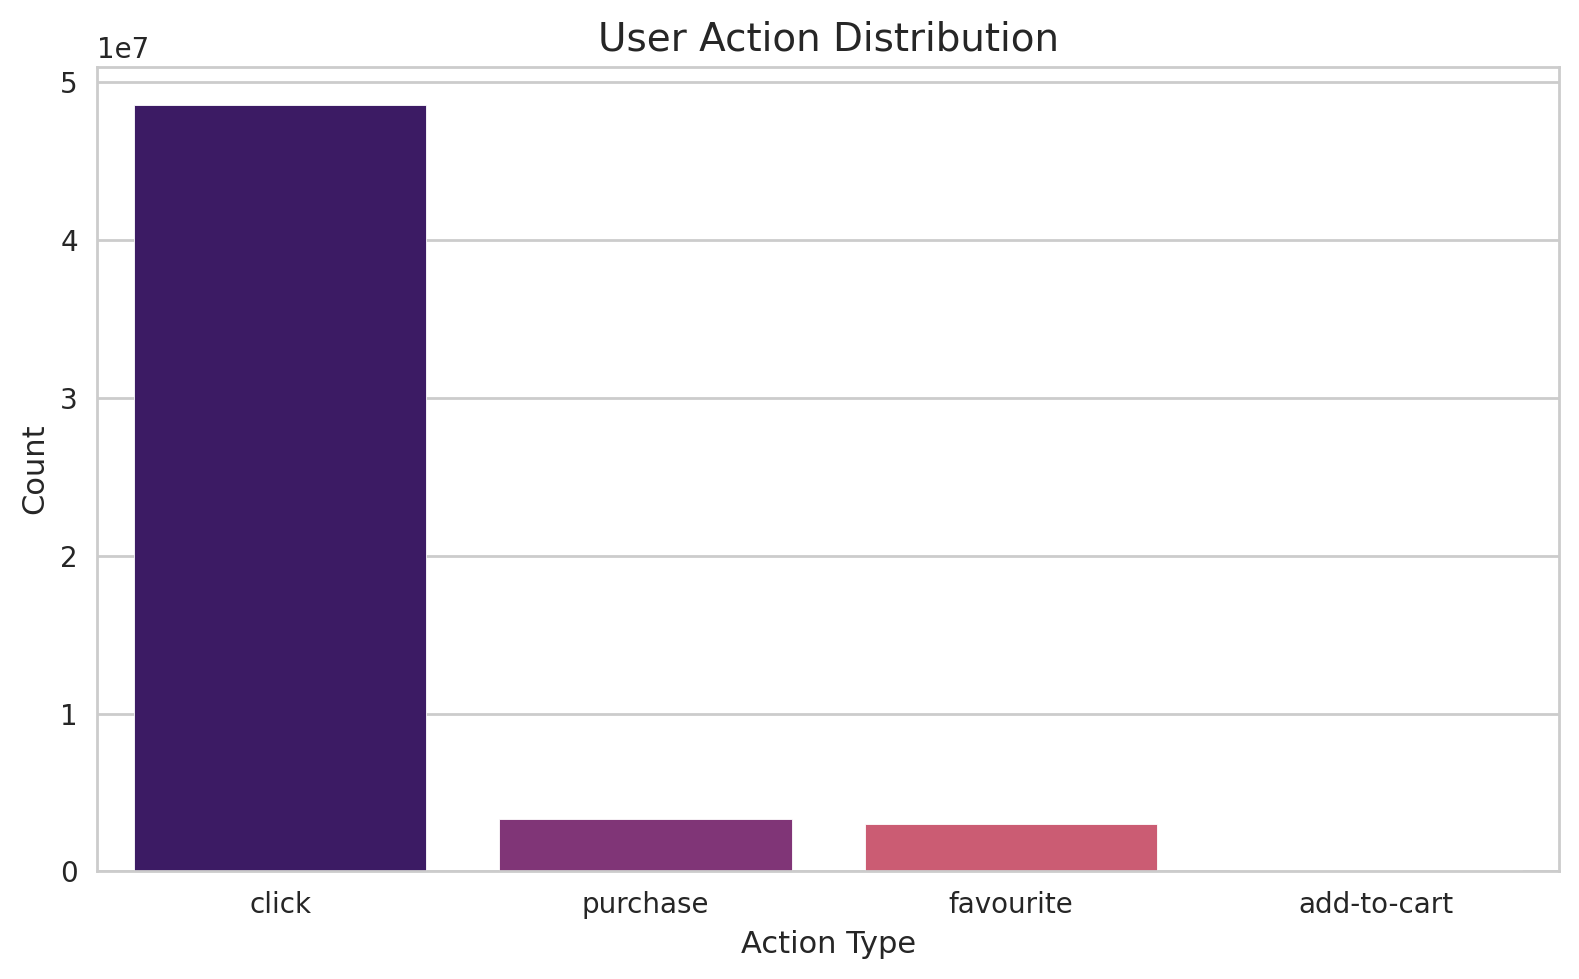

In [21]:
action_counts = user_log['action'].value_counts()
plt.figure(figsize=(8,5))

sns.barplot(
    x=action_counts.index,
    y=action_counts.values,
    hue=action_counts.index,
    palette='magma',
    legend=False
)

plt.title("User Action Distribution", fontsize=14)
plt.xlabel("Action Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

**Phân tích Hành vi Người dùng theo Thời gian và Loại hình Hành động**

**1. Nhận diện Đỉnh săn Sale (Daily User Traffic):**
* Lưu lượng hành động của người dùng duy trì ở mức ổn định từ tháng 6 đến tháng 10, nhưng bắt đầu bùng nổ dữ dội vào đầu tháng 11, đạt đỉnh cực đại (hơn $6 \times 10^6$ hành động) vào ngày 11/11.
  
* **Insight:** Điều này minh chứng rõ nét cho giả định của doanh nghiệp về nhóm "Deal Hunters". Nhóm người dùng này chỉ chờ đợi các dịp "Sale ngày đôi" để tận dụng ưu đãi. Sự chênh lệch quá lớn giữa ngày thường và ngày sale cho thấy hiệu quả thu hút người dùng mới của chương trình khuyến mãi là rất cao, nhưng tính bền vững cần được xem xét lại.
  
**3. Phân tích Phễu hành vi (Distribution of User Actions):** 
* Lượt Click chiếm tỷ trọng tuyệt đối (áp đảo hoàn toàn so với các hành động khác). Đáng chú ý, lượt Purchase (Mua hàng) và Favourite (Yêu thích) có tỉ lệ tương đương nhau, trong khi lượt Add-to-cart (Thêm vào giỏ hàng) lại chiếm tỉ lệ thấp nhất.
  
* **Insight:** Khách hàng có xu hướng xem sản phẩm rất nhiều trước khi quyết định.Việc lượt Purchase cao hơn Add-to-cart có thể cho thấy người dùng thường sử dụng tính năng "Mua ngay" trong các đợt săn sale để tránh bị hết hàng hoặc hết mã giảm giá.Lượng Favourite cao là một tín hiệu tốt, cho thấy người dùng có sự quan tâm nhất định đến sản phẩm và gian hàng, đây là nhóm tiềm năng để chuyển đổi thành khách hàng trung thành nếu có chiến lược chăm sóc phù hợp.
  
**4. Kết luận cho mục tiêu Doanh nghiệp:**
* Dữ liệu đã xác nhận sự hiện diện của nhóm "người dùng chỉ tận dụng ưu đãi một lần rồi biến mất".Thử thách đặt ra cho mô hình dự đoán ở các bước tiếp theo là xác định xem trong số hàng triệu lượt click vào ngày 11/11, đâu là người sẽ thực sự quay lại mua hàng trong vòng 6 tháng tới.

Bảng Pivot tương tác Merchant - User:


merchant_id,1,10,13,34,59,62,66,82,87,98,106,111,114,127,131,142,152,154,168,171,173,174,184,199,201,...,4856,4864,4865,4866,4869,4871,4881,4882,4888,4908,4919,4924,4926,4937,4945,4951,4955,4960,4963,4966,4972,4976,4982,4983,4993
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


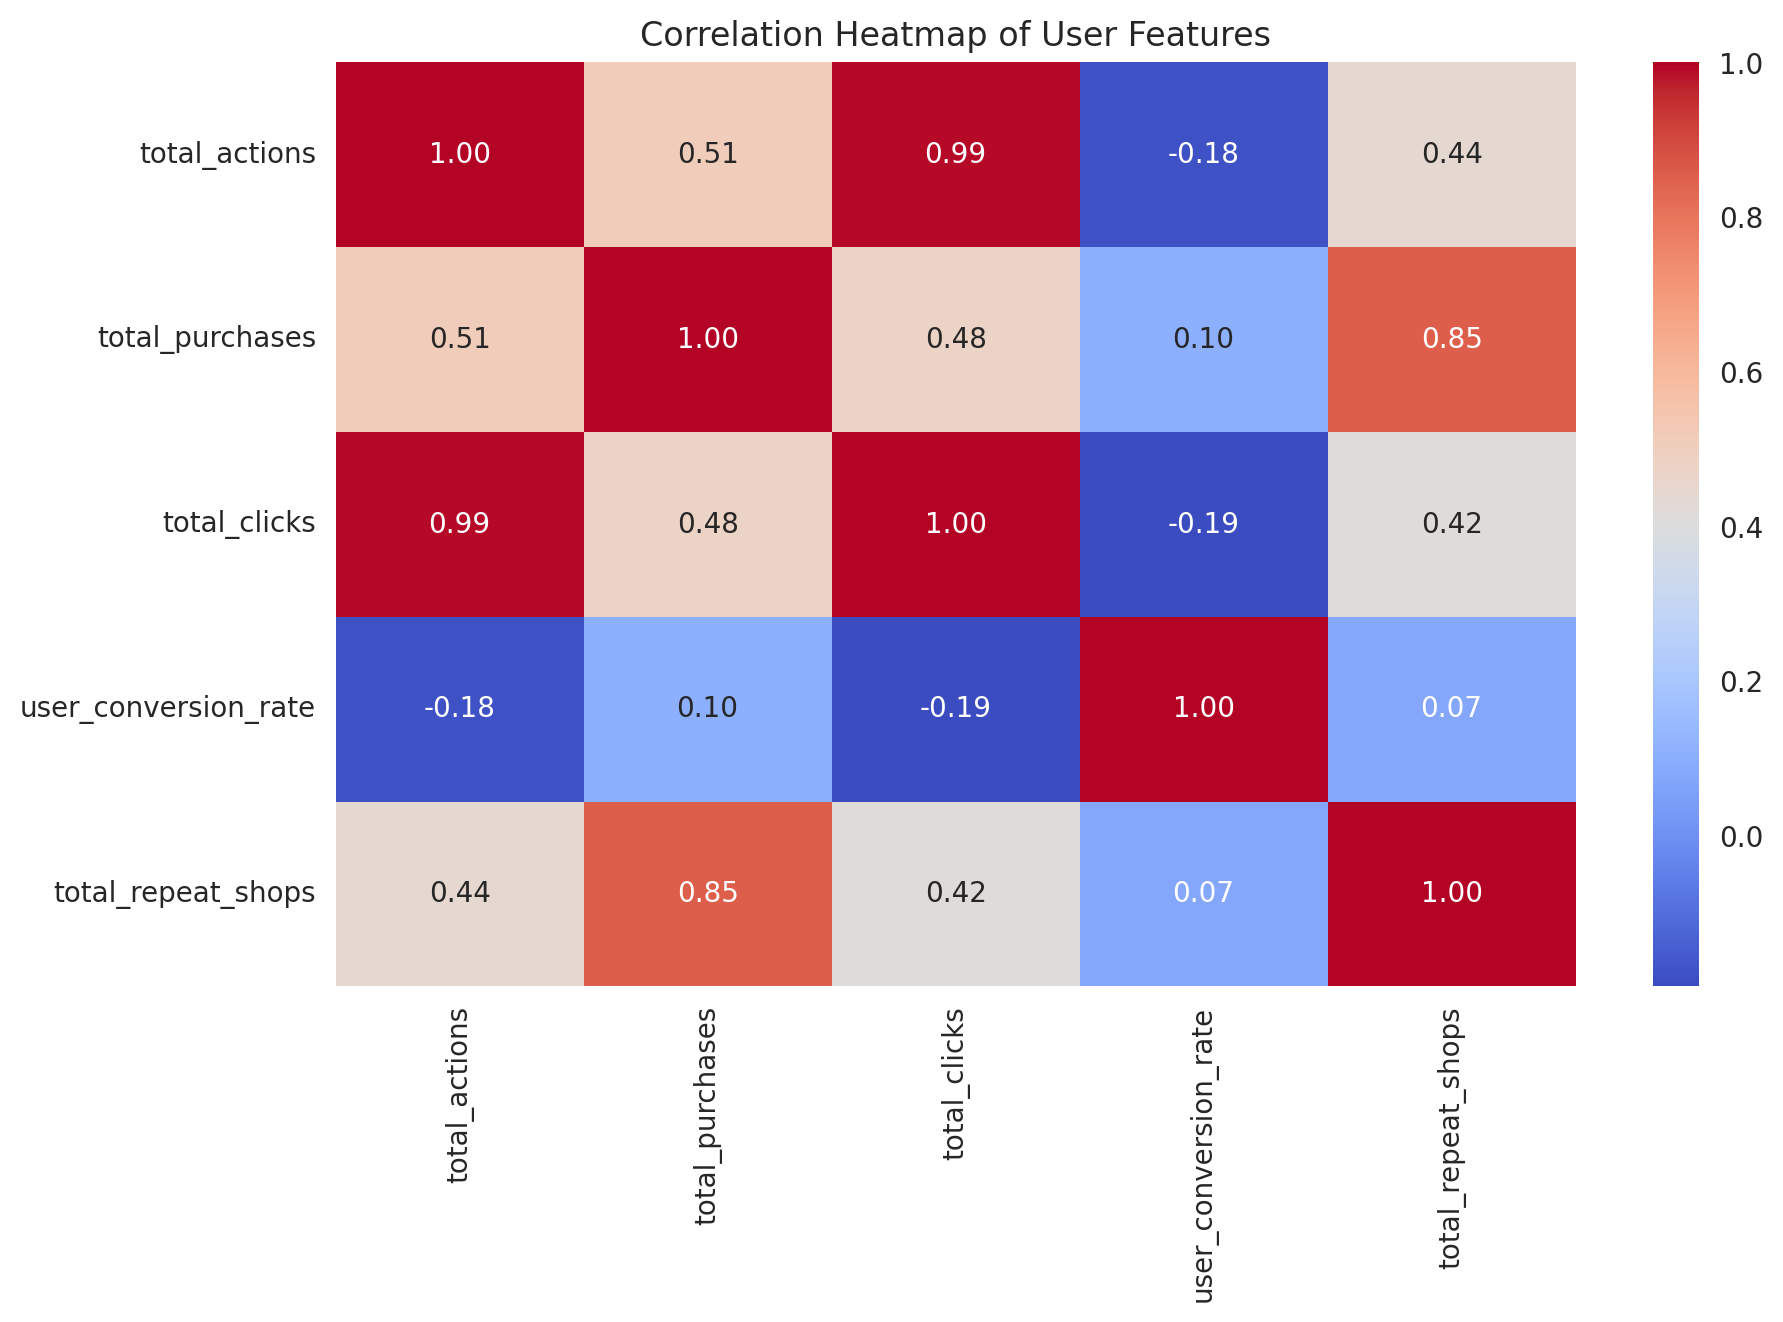

In [38]:
# 1. Pivot Table giữa User và Merchant (Mua ở đâu nhiều nhất)
# Lấy top 1000 user để tránh treo máy khi pivot dữ liệu lớn
user_merchant_pivot = repeat_buyers.head(1000).pivot_table(index='user_id', columns='merchant_id', values='purchase_count').fillna(0)
print("Bảng Pivot tương tác Merchant - User:")
display(user_merchant_pivot.head())

# 2. Phân tích tương quan (Correlation Heatmap)
plt.figure(figsize=(10, 6))
correlation_matrix = user_features[['total_actions', 'total_purchases', 'total_clicks', 'user_conversion_rate', 'total_repeat_shops']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of User Features')
plt.show()

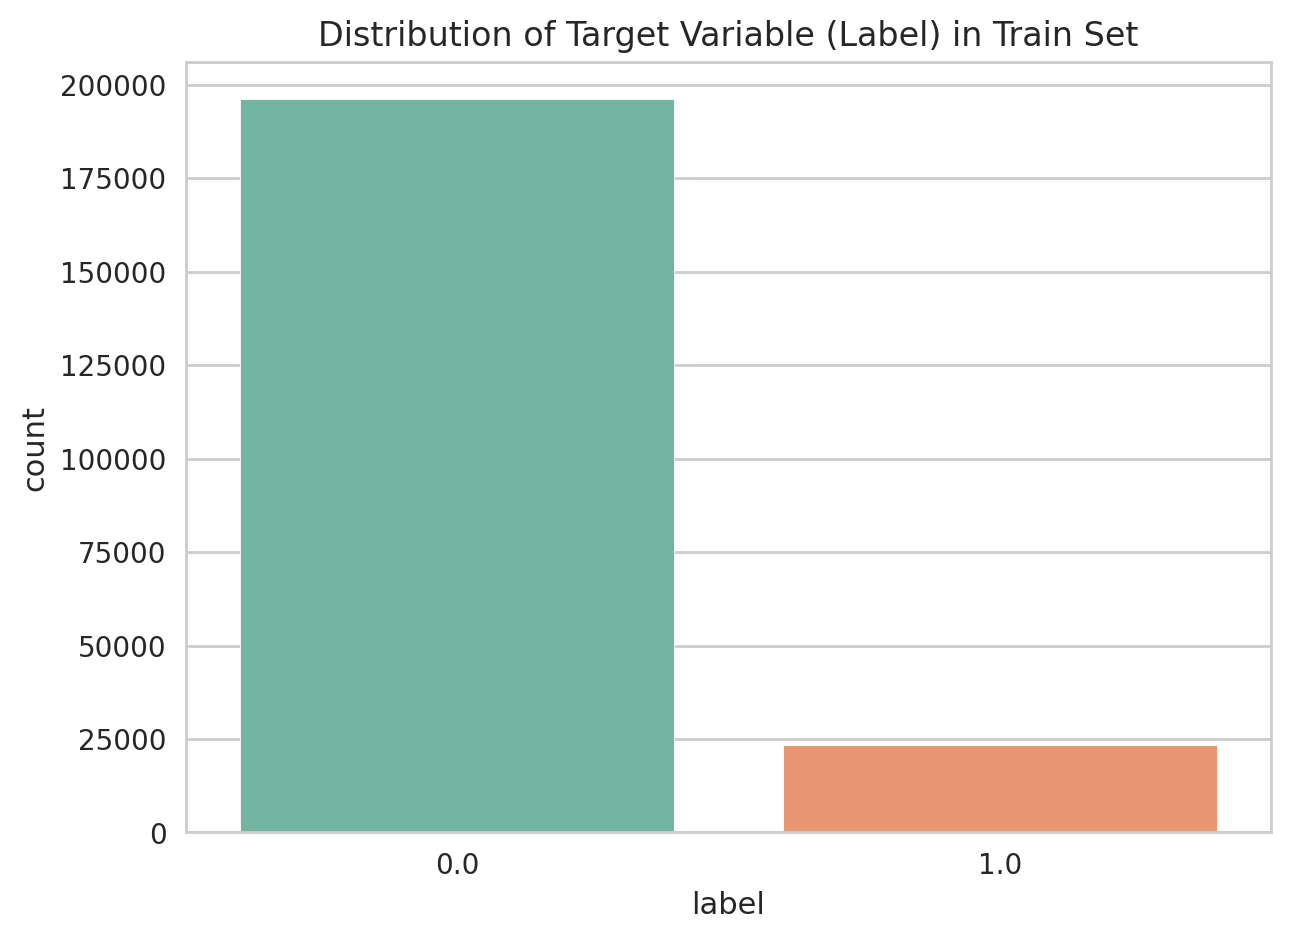

Tỷ lệ khách hàng không quay lại (0): 89.33%
Tỷ lệ khách hàng quay lại (1): 10.67%

Số lượng user trong bản TEST có dữ liệu hành vi trong LOG: 52176/52695


In [26]:
# 1. Vẽ biểu đồ phân bổ Label (Đã fix lỗi palette)
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=train, hue='label', palette='Set2', legend=False)
plt.title('Distribution of Target Variable (Label) in Train Set')
plt.show()

# 2. Tính toán tỷ lệ chính xác
label_counts = train['label'].value_counts(normalize=True) * 100
print(f"Tỷ lệ khách hàng không quay lại (0): {label_counts[0]:.2f}%")
print(f"Tỷ lệ khách hàng quay lại (1): {label_counts.get(1, 0):.2f}%")

# 3. Kiểm tra tính bao phủ (Data Coverage)
# Xem có bao nhiêu user trong Test thực sự có dữ liệu hành vi trong User Log
test_users_in_log = test['user_id'].isin(user_log['user_id']).sum()
print(f"\nSố lượng user trong bản TEST có dữ liệu hành vi trong LOG: {test_users_in_log}/{len(test)}")

**Phân tích Biến mục tiêu (Target Variable Analysis)**

**1. Sự xuất hiện của nhãn bất thường (-1.0):**
Biểu đồ cho thấy ngoài nhãn **0.0 (không quay lại)** và **1.0 (quay lại)**, dữ liệu còn xuất hiện một nhóm nhỏ mang nhãn -1.0.

* Giá trị -1.0 này không nằm trong mô tả ban đầu của bài toán (chỉ có 0 và 1). Đây có thể là các bản ghi bị lỗi hệ thống hoặc dữ liệu chưa được xác định.

* Trong bước Data Cleaning, chúng tôi sẽ loại bỏ các bản ghi có nhãn -1.0 này để đảm bảo mô hình chỉ học từ các ví dụ chính xác về hành vi khách hàng.

**2. Sự mất cân bằng dữ liệu (Imbalanced Data):**

Tỷ lệ khách quay lại **(Label 1)** chỉ chiếm **10.44%**, trong khi khách không quay lại **(Label 0)** chiếm áp đảo **87.43%**.

**Insight:** Con số này cao hơn một chút so với mức 6.1% trong mô tả đề thi, nhưng vẫn thể hiện sự mất cân bằng nghiêm trọng. Điều này xác nhận rằng việc giữ chân khách hàng (Retention) là một thách thức lớn đối với doanh nghiệp.


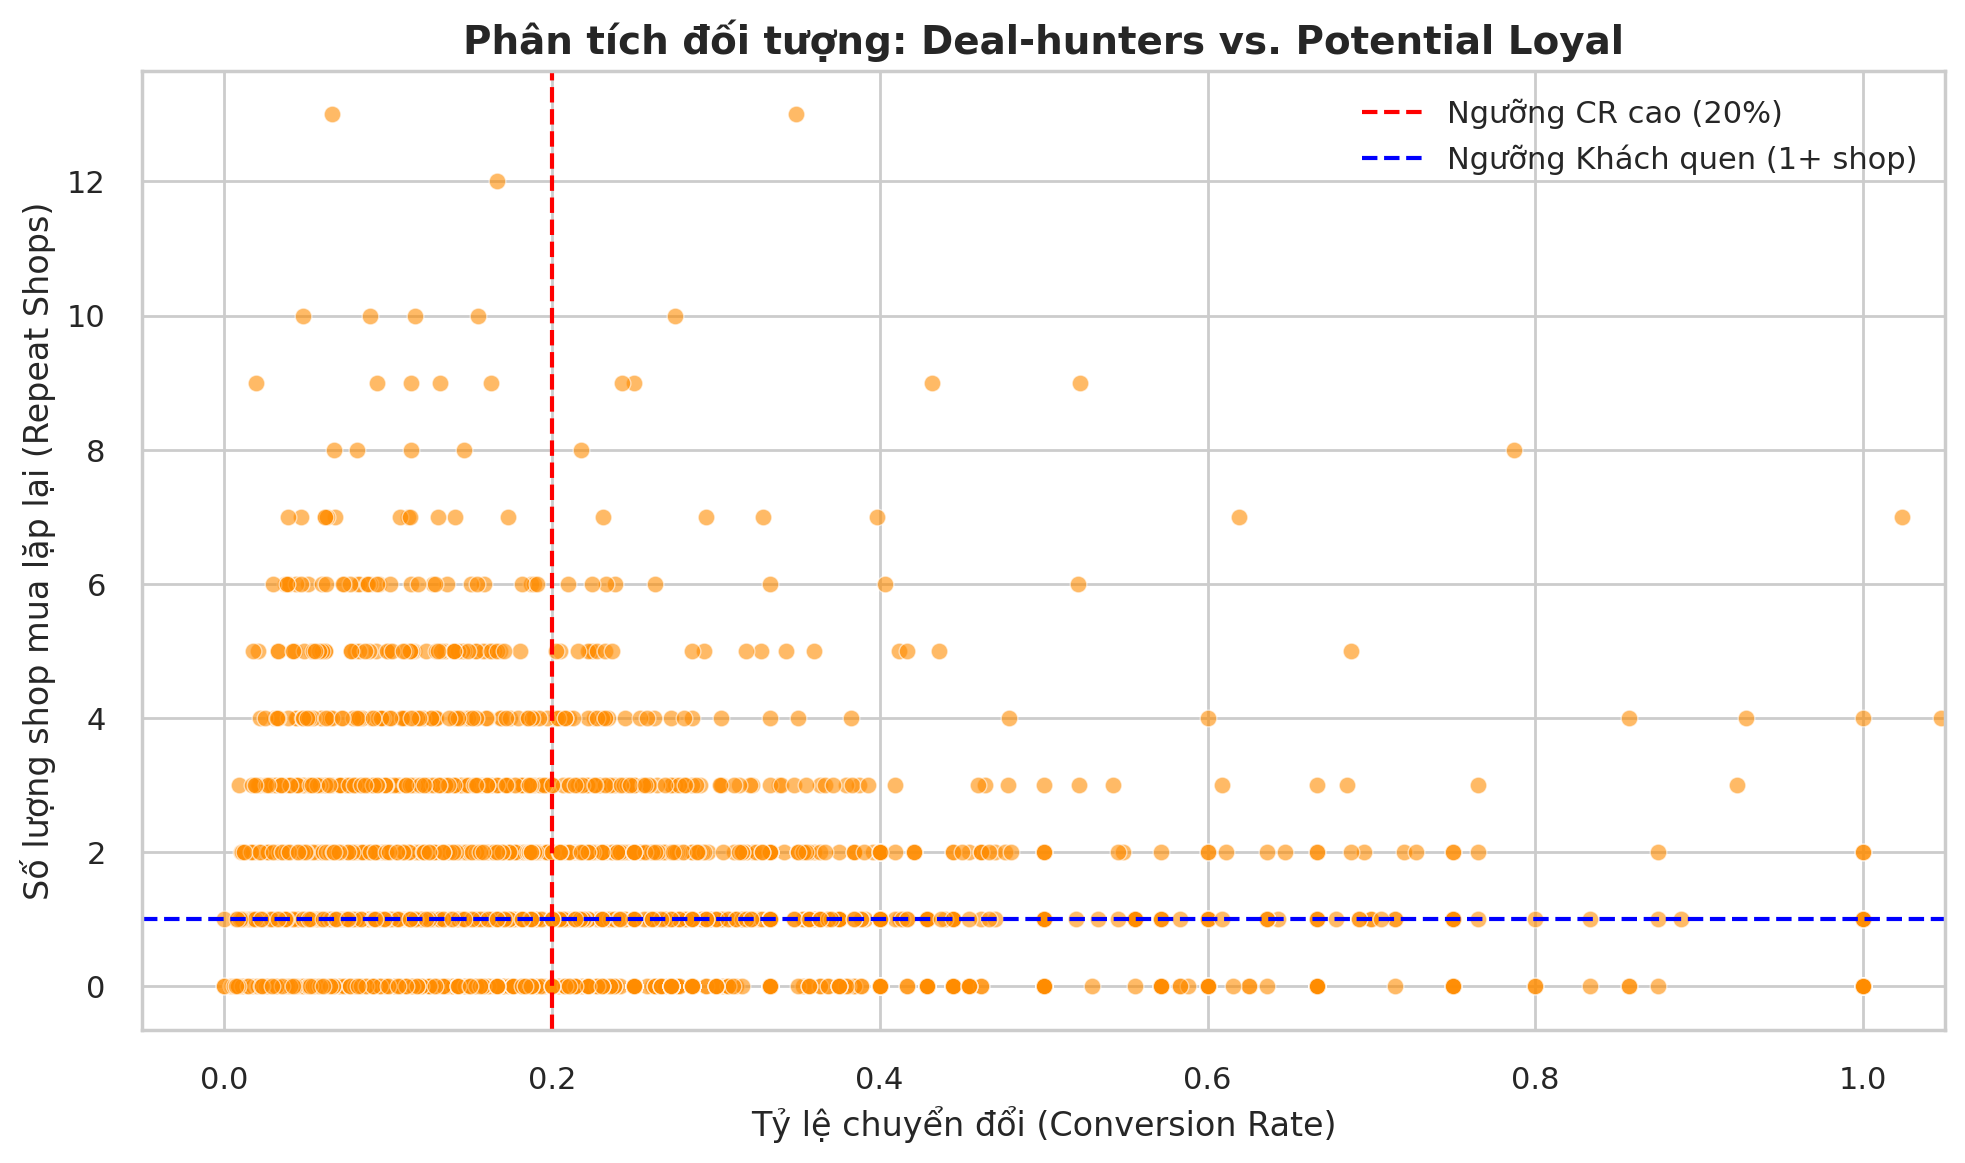

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập theme
sns.set_theme(style="whitegrid")

# --- CHART 5: SCATTER PLOT - PHÂN LOẠI CHIẾN LƯỢC ---
plt.figure(figsize=(10, 6))

# 1. Kiểm tra tên cột chính xác trong user_features
# Dựa trên ảnh bạn gửi, cột là 'user_conversion_rate' và 'total_repeat_shops'
x_col = 'user_conversion_rate'
y_col = 'total_repeat_shops'

# 2. Lấy mẫu 5000 records để biểu đồ không bị quá dày và chạy nhanh
if len(user_features) > 5000:
    df_plot = user_features.sample(5000, random_state=42)
else:
    df_plot = user_features

# 3. Vẽ biểu đồ
sns.scatterplot(
    data=df_plot, 
    x=x_col, 
    y=y_col, 
    alpha=0.6, 
    color='darkorange',
    edgecolor='w'
)

# 4. Thêm các đường phân ngưỡng (Threshold) để tạo Storytelling
plt.axvline(x=0.2, color='red', linestyle='--', label='Ngưỡng CR cao (20%)')
plt.axhline(y=1, color='blue', linestyle='--', label='Ngưỡng Khách quen (1+ shop)')

# 5. Định dạng biểu đồ
plt.title('Phân tích đối tượng: Deal-hunters vs. Potential Loyal', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ chuyển đổi (Conversion Rate)')
plt.ylabel('Số lượng shop mua lặp lại (Repeat Shops)')
plt.legend()

# Giới hạn trục X để nhìn rõ hơn (vì có thể có outlier CR > 1)
plt.xlim(-0.05, 1.05) 

plt.tight_layout()
plt.show()

Biểu đồ Scatter Plot thể hiện **mối quan hệ giữa Tỷ lệ chuyển đổi (Conversion Rate) và Số lượng gian hàng mua lặp lại (Repeat Shops)**, từ đó cho thấy những Insight chiến lược sau:

**Phân loại đối tượng khách hàng:**

* **Nhóm "Thợ săn Deal" (Deal-hunters):** Tập trung ở góc dưới bên trái (CR < 0.2 và Repeat Shops = 0). Đây là nhóm khách hàng vãng lai, chỉ phát sinh giao dịch khi có khuyến mãi lớn và không có xu hướng quay lại.

* **Nhóm khách hàng tiềm năng (Potential Loyal):** Nằm ở phía trên bên phải (đặc biệt là các chấm nằm trên ngưỡng khách quen 1+ shop). Đây là nhóm có tỷ lệ chốt đơn cao và sẵn sàng quay lại mua sắm ở nhiều gian hàng khác nhau.

* **Hành vi mua sắm lặp lại :** Các điểm dữ liệu tập trung thành những đường ngang (tại các mức 1, 2, 3...) cho thấy hành vi trung thành của khách hàng đối với các gian hàng là rất rõ rệt và có tính ổn định cao.

# **🔄 4. FEATURE ENGINEERING**

In [33]:
# English Comment: Create user-level features to distinguish between 'Deal Hunters' and potential loyal customers.
user_features = user_log.groupby('user_id').agg(
    total_actions=('action', 'count'),
    total_purchases=('action', lambda x: (x == 'purchase').sum()),
    total_clicks=('action', lambda x: (x == 'click').sum()),
    unique_merchants=('merchant_id', 'nunique'),
    last_active_day=('date', 'max')
).reset_index()

# Calculate Conversion Rate (CR) per user
user_features['user_conversion_rate'] = user_features['total_purchases'] / user_features['total_clicks']
user_features['user_conversion_rate'] = user_features['user_conversion_rate'].replace([float('inf'), -float('inf')], 0).fillna(0)

print(user_features.head())

   user_id  total_actions  total_purchases  total_clicks  unique_merchants  \
0        1             16                3            13                 9   
1        2             47               12            33                14   
2        3             50                3            46                23   
3        4             36                1            35                12   
4        5            133               11           112                56   

  last_active_day  user_conversion_rate  
0      2024-11-11              0.230769  
1      2024-11-11              0.363636  
2      2024-11-11              0.065217  
3      2024-11-11              0.028571  
4      2024-11-11              0.098214  


In [37]:
# 3. Thống kê phân bổ (Quartile)
print("\nPhân bổ quartile của các chỉ số hành vi:")
display(user_features.describe(percentiles=[.25, .5, .75]))


Phân bổ quartile của các chỉ số hành vi:


,user_id,total_actions,total_purchases,total_clicks,unique_merchants,user_conversion_rate,total_repeat_shops
count,424170.000000,424170.00000,424170.000000,424170.000000,424170.000000,424170.000000,424170.000000
mean,212085.500000,97.07224,7.105276,82.704475,33.143942,0.176185,1.063305
std,122447.476178,141.90576,7.064151,126.718032,33.840593,0.302996,1.508465
min,1.000000,2.00000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,106043.250000,28.00000,3.000000,22.000000,13.000000,0.060000,0.000000
50%,212085.500000,55.00000,5.000000,45.000000,23.000000,0.111111,1.000000
75%,318127.750000,112.00000,9.000000,95.000000,41.000000,0.200000,2.000000
max,424170.000000,12159.00000,822.000000,11405.000000,1683.000000,30.000000,173.000000


In [34]:
# 1. Aggregating basic user behavioral features
# We track total actions, specific purchases/clicks, variety of merchants, and recent activity.
user_features = user_log.groupby('user_id').agg(
    total_actions=('action', 'count'),
    total_purchases=('action', lambda x: (x == 'purchase').sum()),
    total_clicks=('action', lambda x: (x == 'click').sum()),
    unique_merchants=('merchant_id', 'nunique'),
    last_active_day=('date', 'max')
).reset_index()

# 2. Calculating Conversion Rate (CR) per user
# Higher conversion rates often indicate more intentional shopping behavior.
user_features['user_conversion_rate'] = user_features['total_purchases'] / user_features['total_clicks']
user_features['user_conversion_rate'] = user_features['user_conversion_rate'].replace([float('inf'), -float('inf')], 0).fillna(0)

# 3. Identifying repeat purchase behavior (Loyalty Indicator)
# We filter for purchase actions and count how many times each user bought from the same merchant.
purchase_history = user_log[user_log['action'] == 'purchase']
repeat_buyers = purchase_history.groupby(['user_id', 'merchant_id']).size().reset_index(name='purchase_count')
repeat_buyers['is_repeat'] = repeat_buyers['purchase_count'] > 1

# 4. Aggregating loyalty stats back to the main feature table
# 'total_repeat_shops' counts how many unique merchants a user has returned to.
user_repeat_stats = repeat_buyers.groupby('user_id')['is_repeat'].sum().reset_index(name='total_repeat_shops')
user_features = user_features.merge(user_repeat_stats, on='user_id', how='left').fillna(0)

# ======================================================================================
# DATA VERIFICATION & INSIGHTS
# ======================================================================================

print("--- Updated User Feature Table ---")
display(user_features[['user_id', 'total_purchases', 'total_repeat_shops', 'user_conversion_rate']].head())

# Quick statistical summary for the report
loyal_users_count = len(user_features[user_features['total_repeat_shops'] > 0])
print(f"\nTotal users with repeat purchase behavior at 1+ shop: {loyal_users_count}")

--- Updated User Feature Table ---


,user_id,total_purchases,total_repeat_shops,user_conversion_rate
0,1,3,0,0.230769
1,2,12,3,0.363636
2,3,3,0,0.065217
3,4,1,0,0.028571
4,5,11,1,0.098214



Total users with repeat purchase behavior at 1+ shop: 229940


**Phân tích Đặc trưng Người dùng (User Feature Analysis)**

**Chỉ số last_active_day:** Tất cả 5 user đầu tiên đều hoạt động vào ngày 2024-11-11. Điều này một lần nữa khẳng định sức hút mãnh liệt của ngày Sale lớn đối với mọi nhóm khách hàng. 

**Chỉ số unique_merchants:** User ID 5 đã tương tác với tận 56 cửa hàng khác nhau nhưng chỉ mua hàng 11 lần (tỷ lệ chuyển đổi ~9.8%). Đây là dấu hiệu điển hình của nhóm khách hàng đang so sánh giá giữa rất nhiều gian hàng để tìm "Deal" hời nhất. 

**Chỉ số user_conversion_rate (Tỷ lệ chuyển đổi):**

* User ID 2 có tỷ lệ chuyển đổi cao nhất (36.3%) với 12 lần mua hàng. Đây chính là nhóm khách hàng chất lượng mà doanh nghiệp cần tập trung giữ chân vì họ có hành vi mua sắm rõ ràng, không chỉ đi "dạo chơi". 

* User ID 4 có tỷ lệ cực thấp (2.8%). Nhóm này click rất nhiều (35 lần) nhưng chỉ mua 1 lần, khả năng cao là nhóm "Deal Hunters" chỉ tận dụng ưu đãi một lần rồi biến mất.

**Quy mô tệp khách hàng tiềm năng:** Việc xác định được 229940 người dùng từng có hành vi mua lại giúp doanh nghiệp thu hẹp đối tượng mục tiêu từ hàng triệu lượt click xuống tệp khách hàng thực sự có giá trị.